# **Cartly: E-Commerce Conversion Funnel & User Behavior Analysis**

## 📦 Cartly E-Commerce — Data Overview


---

## 🏪 About Cartly

**Cartly** is a fictional e-commerce company that sells **digital products** — online courses, e-books, templates, and software tools.

In this first notebook, we take a **bird's-eye view** of all five datasets to understand:
- What data we have
- How many records exist in each table
- The shape and quality of each dataset
- Early observations that will guide deeper analysis

---

### 📁 Datasets
| File | Description |
|------|-------------|
| `users.csv` | Registered users with demographics & acquisition source |
| `sessions.csv` | Web sessions — duration, pages viewed, bounce |
| `events.csv` | User actions — page views, clicks, add-to-cart, purchases |
| `products.csv` | Product catalog with categories and pricing |
| `transactions.csv` | Purchase records with amount, discount, payment method |

## 🔧 Step 1 — Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# Global plot style
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 12

print('✅ Libraries imported successfully!')

✅ Libraries imported successfully!


## 📥 Step 2 — Load All Datasets

We load all five CSVs into pandas DataFrames. We also parse any date columns right away so we can use them directly in time-based analysis later.

In [2]:
# ---------- Load all datasets ----------
users        = pd.read_csv('E:/Data Analyst Projects/Projects/Cartly Analytics/Data/users.csv', parse_dates=['signup_date'])
sessions     = pd.read_csv('E:/Data Analyst Projects/Projects/Cartly Analytics/Data/sessions.csv', parse_dates=['session_start_time', 'session_end_time', 'session_date'])
events       = pd.read_csv('E:/Data Analyst Projects/Projects/Cartly Analytics/Data/events.csv', parse_dates=['event_time'])
products     = pd.read_csv('E:/Data Analyst Projects/Projects/Cartly Analytics/Data/products.csv', parse_dates=['created_date'])
transactions = pd.read_csv('E:/Data Analyst Projects/Projects/Cartly Analytics/Data/transactions.csv', parse_dates=['purchase_date'])

print('✅ All datasets loaded!')
print()
print('Dataset sizes:')
for name, df in [('users', users), ('sessions', sessions), ('events', events),
                 ('products', products), ('transactions', transactions)]:
    print(f'  {name}  →  {df.shape[0]} rows  ×  {df.shape[1]} columns')

✅ All datasets loaded!

Dataset sizes:
  users  →  10000 rows  ×  8 columns
  sessions  →  100000 rows  ×  9 columns
  events  →  500000 rows  ×  7 columns
  products  →  200 rows  ×  8 columns
  transactions  →  30000 rows  ×  9 columns


---
## 👥 Step 3 — Users Dataset

The `users` table is the foundation. It tells us **who** our customers are — their demographics, which device they use, and how they found Cartly.

In [3]:
print('--- First 5 rows ---')
users.head()

--- First 5 rows ---


,user_id,signup_date,country,city,age_group,gender,device_type,acquisition_source
0,U00001,2024-03-22,UK,London,25-34,Male,Mobile,Referral
1,U00002,2022-11-17,India,Mumbai,45-60,Female,Mobile,Organic
2,U00003,2023-03-20,India,Hyderabad,25-34,Female,Desktop,Paid Ads
3,U00004,2024-08-20,Australia,Melbourne,35-44,Female,Mobile,Organic
4,U00005,2024-04-11,India,Mumbai,25-34,Male,Mobile,Paid Ads


In [4]:
print('--- Column types & non-null counts ---')
users.info()

--- Column types & non-null counts ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   user_id             10000 non-null  object        
 1   signup_date         10000 non-null  datetime64[ns]
 2   country             10000 non-null  object        
 3   city                10000 non-null  object        
 4   age_group           10000 non-null  object        
 5   gender              10000 non-null  object        
 6   device_type         10000 non-null  object        
 7   acquisition_source  10000 non-null  object        
dtypes: datetime64[ns](1), object(7)
memory usage: 625.1+ KB


In [5]:
print('--- Summary statistics (categorical) ---')
users.describe(include='object')

--- Summary statistics (categorical) ---


,user_id,country,city,age_group,gender,device_type,acquisition_source
count,10000,10000,10000,10000,10000,10000,10000
unique,10000,6,43,4,3,3,4
top,U09984,India,Ahmedabad,25-34,Male,Mobile,Organic
freq,1,4057,544,3846,5204,6508,3484


### 📊 Visualisation — Device Type & Acquisition Source

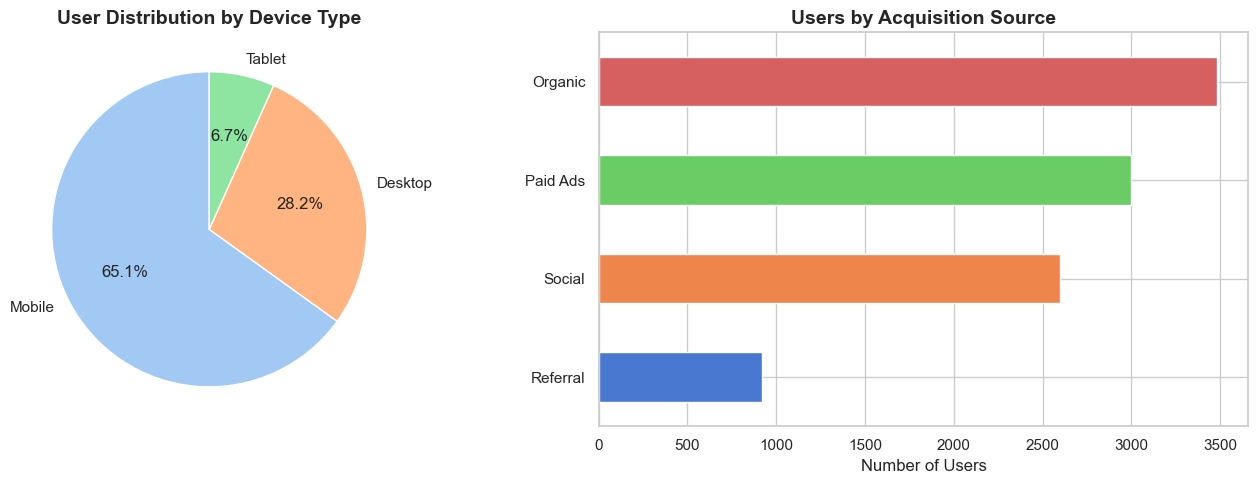

Chart saved.


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Device Type ---
device_counts = users['device_type'].value_counts()
axes[0].pie(
    device_counts,
    labels=device_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=sns.color_palette('pastel')
)
axes[0].set_title('User Distribution by Device Type', fontsize=14, fontweight='bold')

# --- Acquisition Source ---
acq_counts = users['acquisition_source'].value_counts().sort_values()
acq_counts.plot(kind='barh', ax=axes[1], color=sns.color_palette('muted'))
axes[1].set_title('Users by Acquisition Source', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Number of Users')
axes[1].set_ylabel('')

plt.tight_layout()
plt.savefig('E:\\Data Analyst Projects\\Projects\\Cartly Analytics\\report\\01_users_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved.')

### 💡 Business Insight — Users

> **65% of users access Cartly via Mobile** — this is the dominant device. Any UX friction on mobile (slow load times, small buttons, non-responsive checkout) directly impacts the majority of the customer base.
>
> **Organic and Referral are strong acquisition channels** — this means word-of-mouth and SEO are working. Paid ads may need ROI evaluation to determine if the spend justifies the user volume.

---
## 🌐 Step 4 — Sessions Dataset

Sessions capture **how users behave** when they visit the site — how long they stay, how many pages they browse, and whether they immediately leave (bounce).

In [7]:
sessions.head()

,session_id,user_id,session_start_time,session_end_time,session_date,pages_viewed,time_spent_seconds,bounce_flag,traffic_source
0,S000001,U09128,2023-03-04 19:47:00,2023-03-04 19:47:20,2023-03-04,1,20,1,Paid
1,S000002,U08453,2024-07-06 07:58:00,2024-07-06 07:58:57,2024-07-06,1,57,1,Social
2,S000003,U07131,2024-01-04 06:44:00,2024-01-04 07:30:26,2024-01-04,6,2786,0,Paid
3,S000004,U06445,2024-11-04 20:43:00,2024-11-04 20:43:14,2024-11-04,1,14,1,Direct
4,S000005,U04039,2024-05-21 11:00:00,2024-05-21 11:00:12,2024-05-21,1,12,1,Social


In [8]:
sessions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   session_id          100000 non-null  object        
 1   user_id             100000 non-null  object        
 2   session_start_time  100000 non-null  datetime64[ns]
 3   session_end_time    100000 non-null  datetime64[ns]
 4   session_date        100000 non-null  datetime64[ns]
 5   pages_viewed        100000 non-null  int64         
 6   time_spent_seconds  100000 non-null  int64         
 7   bounce_flag         100000 non-null  int64         
 8   traffic_source      100000 non-null  object        
dtypes: datetime64[ns](3), int64(3), object(3)
memory usage: 6.9+ MB


In [9]:
sessions[['pages_viewed', 'time_spent_seconds', 'bounce_flag']].describe().round(2)

,pages_viewed,time_spent_seconds,bounce_flag
count,100000.00,100000.00,100000.00
mean,3.69,1107.18,0.40
std,4.00,1184.11,0.49
min,1.00,5.00,0.00
25%,1.00,39.00,0.00
50%,2.00,637.00,0.00
75%,5.00,2123.00,1.00
max,20.00,3600.00,1.00


### 📊 Visualisation — Traffic Source Distribution

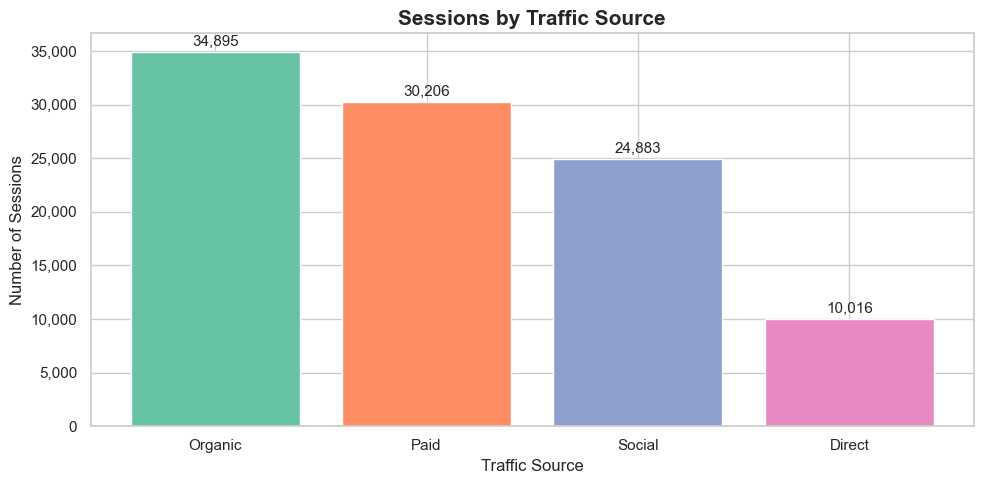

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))

traffic_counts = sessions['traffic_source'].value_counts()
bars = ax.bar(traffic_counts.index, traffic_counts.values,
              color=sns.color_palette('Set2', len(traffic_counts)))

# Add value labels on bars
for bar in bars:
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 300,
            f'{int(bar.get_height()):,}',
            ha='center', va='bottom', fontsize=11)

ax.set_title('Sessions by Traffic Source', fontsize=15, fontweight='bold')
ax.set_xlabel('Traffic Source')
ax.set_ylabel('Number of Sessions')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.tight_layout()
plt.savefig('E:\\Data Analyst Projects\\Projects\\Cartly Analytics\\report\\01_sessions_traffic.png', dpi=150, bbox_inches='tight')
plt.show()


### 💡 Business Insight — Sessions

> **Organic traffic drives the most sessions (~35%)**, confirming that SEO and content marketing are working for Cartly.
>
> **Direct traffic is the lowest (~10%)** — this suggests limited brand recall. Investing in brand awareness could convert more users to direct, loyal visitors.

---
## 🖱️ Step 5 — Events Dataset

Events are the **granular actions** users take — viewing a page, clicking a product, adding to cart, and initiating a purchase. This is the richest dataset and will power our funnel analysis.

In [11]:
events.head()

,event_id,user_id,session_id,product_id,event_time,event_type,page_name
0,E000001,U09128,S000001,NaN,2023-03-04 19:47:17,page_view,Landing Page
1,E000002,U08453,S000002,NaN,2024-07-06 07:58:35,page_view,Home
2,E000003,U06445,S000004,NaN,2024-11-04 20:43:02,page_view,Home
3,E000004,U04039,S000005,NaN,2024-05-21 11:00:07,page_view,Home
4,E000005,U00276,S000007,NaN,2024-01-29 12:56:02,page_view,Landing Page


In [12]:
events.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Data columns (total 7 columns):
 #   Column      Non-Null Count   Dtype         
---  ------      --------------   -----         
 0   event_id    500000 non-null  object        
 1   user_id     500000 non-null  object        
 2   session_id  500000 non-null  object        
 3   product_id  142501 non-null  object        
 4   event_time  500000 non-null  datetime64[ns]
 5   event_type  500000 non-null  object        
 6   page_name   500000 non-null  object        
dtypes: datetime64[ns](1), object(6)
memory usage: 26.7+ MB


In [13]:
# Event type breakdown
event_counts = events['event_type'].value_counts().reset_index()
event_counts.columns = ['event_type', 'count']
event_counts['pct'] = (event_counts['count'] / event_counts['count'].sum() * 100).round(1)
print(event_counts.to_string(index=False))

    event_type  count  pct
     page_view 443077 88.6
 product_click  36085  7.2
   add_to_cart  14976  3.0
purchase_click   5862  1.2


### 📊 Visualisation — Event Type Distribution

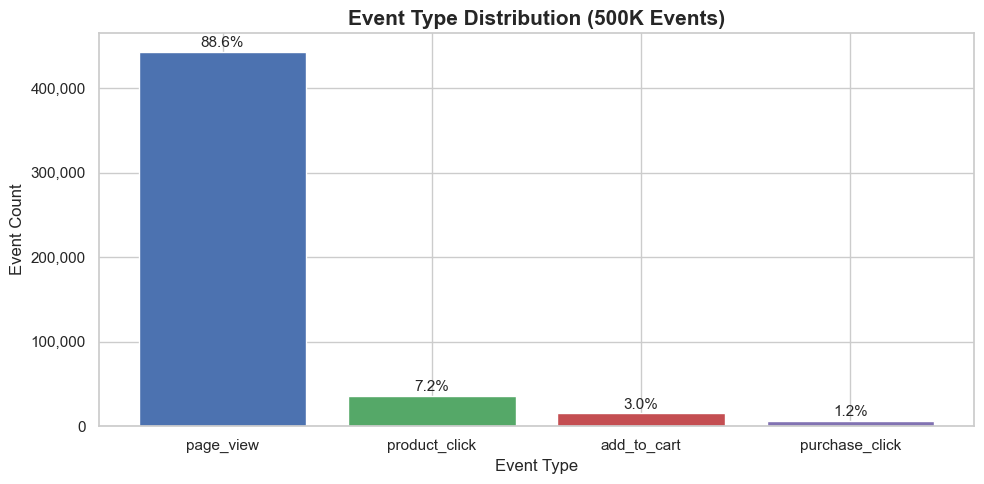

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))

colors = ['#4C72B0', '#55A868', '#C44E52', '#8172B2']
bars = ax.bar(event_counts['event_type'], event_counts['count'], color=colors)

for bar, pct in zip(bars, event_counts['pct']):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 2000,
            f'{pct}%',
            ha='center', va='bottom', fontsize=11)

ax.set_title('Event Type Distribution (500K Events)', fontsize=15, fontweight='bold')
ax.set_xlabel('Event Type')
ax.set_ylabel('Event Count')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.tight_layout()
plt.savefig('E:\\Data Analyst Projects\\Projects\\Cartly Analytics\\report\\01_events_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

### 💡 Business Insight — Events

> **88.6% of all events are page views** — most users are just browsing, not buying. There is a massive drop-off from viewing to purchasing, which we will quantify precisely in the Funnel Analysis notebook.
>
> **Only ~1.2% of events are purchase clicks** — this is our most important metric. Improving this number is directly tied to revenue growth.

---
## 🛍️ Step 6 — Products Dataset

The product catalog tells us what Cartly sells, how it's categorised, and at what price.

In [15]:
products.head()

,product_id,product_name,category,sub_category,price,rating,created_date,is_active
0,P0001,Python for Analysts,Course,Data Science,9100,3.1,2022-06-22,1
1,P0002,SQL Mastery,Course,Data Science,4500,3.4,2023-01-16,0
2,P0003,Machine Learning A-Z,Course,Data Science,2300,4.5,2024-11-17,1
3,P0004,Power BI Bootcamp,Course,Data Science,7900,4.2,2022-05-16,1
4,P0005,Data Viz with Tableau,Course,Data Science,1400,3.2,2022-02-16,1


In [16]:
products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   product_id    200 non-null    object        
 1   product_name  200 non-null    object        
 2   category      200 non-null    object        
 3   sub_category  200 non-null    object        
 4   price         200 non-null    int64         
 5   rating        200 non-null    float64       
 6   created_date  200 non-null    datetime64[ns]
 7   is_active     200 non-null    int64         
dtypes: datetime64[ns](1), float64(1), int64(2), object(4)
memory usage: 12.6+ KB


In [17]:
products[['price', 'rating']].describe().round(2)

,price,rating
count,200.00,200.00
mean,2585.50,3.97
std,2392.46,0.59
min,200.00,3.00
25%,800.00,3.50
50%,1800.00,3.95
75%,3925.00,4.50
max,9900.00,5.00


In [18]:
print('Category breakdown:')
print(products['category'].value_counts())
print()
print(f"Active products : {products['is_active'].sum()}")
print(f"Inactive products: {(products['is_active'] == 0).sum()}")

Category breakdown:
category
Course           55
Ebook            52
Software Tool    50
Template         43
Name: count, dtype: int64

Active products : 185
Inactive products: 15


### 📊 Visualisation — Price Distribution by Category

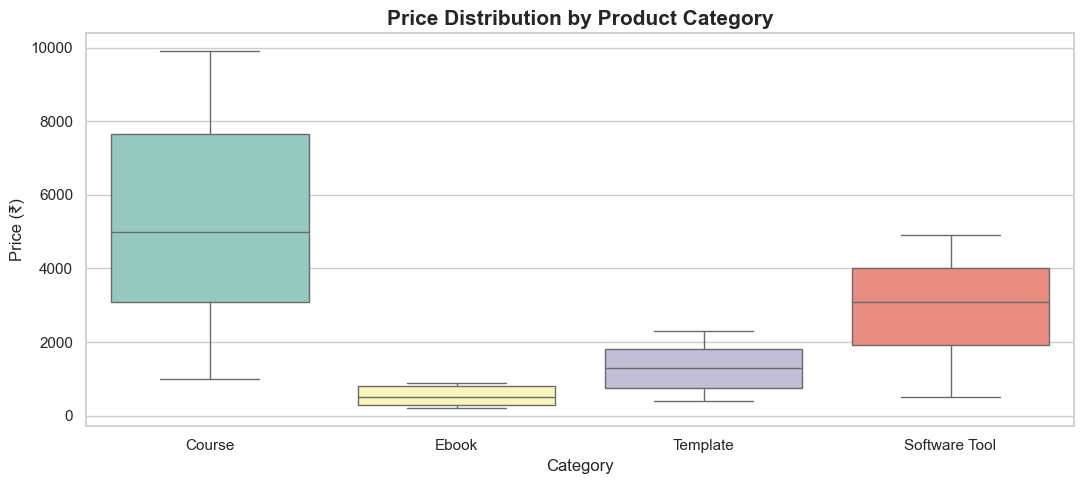

In [ ]:
fig, ax = plt.subplots(figsize=(11, 5))

sns.boxplot(data=products, x='category', y='price', palette='Set3', ax=ax)

ax.set_title('Price Distribution by Product Category', fontsize=15, fontweight='bold')
ax.set_xlabel('Category')
ax.set_ylabel('Price (₹)')

plt.tight_layout()
plt.savefig('E:\\Data Analyst Projects\\Projects\\Cartly Analytics\\report\\01_products_price_dist.png', dpi=150, bbox_inches='tight')
plt.show()

### 💡 Business Insight — Products

> **The product catalog has wide price variance within each category** — this is healthy as it caters to both budget and premium customers.
>
> **Some products are inactive** — reviewing these could either reveal discontinuation opportunities or products that need reactivation with updated content.

---
## 💳 Step 7 — Transactions Dataset

Transactions are the **heartbeat of the business** — every successful purchase is recorded here with the amount paid, discounts applied, and payment method used.

In [20]:
transactions.head()

,transaction_id,user_id,product_id,purchase_date,quantity,amount,discount_amount,payment_method,order_status
0,T00001,U09442,P0013,2024-04-13 08:32:09,1,1760.0,440.0,NetBanking,Success
1,T00002,U04316,P0071,2024-06-01 15:25:36,1,800.0,0.0,Card,Success
2,T00003,U09292,P0069,2023-11-16 12:51:27,2,1620.0,180.0,Card,Success
3,T00004,U00666,P0072,2024-06-28 10:07:17,1,810.0,90.0,NetBanking,Success
4,T00005,U00932,P0127,2024-05-27 22:05:30,1,950.0,50.0,Wallet,Success


In [21]:
transactions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   transaction_id   30000 non-null  object        
 1   user_id          30000 non-null  object        
 2   product_id       30000 non-null  object        
 3   purchase_date    30000 non-null  datetime64[ns]
 4   quantity         30000 non-null  int64         
 5   amount           30000 non-null  float64       
 6   discount_amount  30000 non-null  float64       
 7   payment_method   30000 non-null  object        
 8   order_status     30000 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(5)
memory usage: 2.1+ MB


In [22]:
transactions[['quantity', 'amount', 'discount_amount']].describe().round(2)

,quantity,amount,discount_amount
count,30000.00,30000.00,30000.00
mean,1.25,2925.99,290.18
std,0.53,3241.35,513.61
min,1.00,140.00,0.00
25%,1.00,760.00,0.00
50%,1.00,1800.00,100.00
75%,1.00,3960.00,360.00
max,3.00,29700.00,8100.00


In [23]:
print('Order status breakdown:')
print(transactions['order_status'].value_counts())
print()
print('Payment method breakdown:')
print(transactions['payment_method'].value_counts())

Order status breakdown:
order_status
Success     26935
Failed       1558
Refunded     1507
Name: count, dtype: int64

Payment method breakdown:
payment_method
UPI           11991
Card          10463
Wallet         4519
NetBanking     3027
Name: count, dtype: int64


### 📊 Visualisation — Payment Method Preference

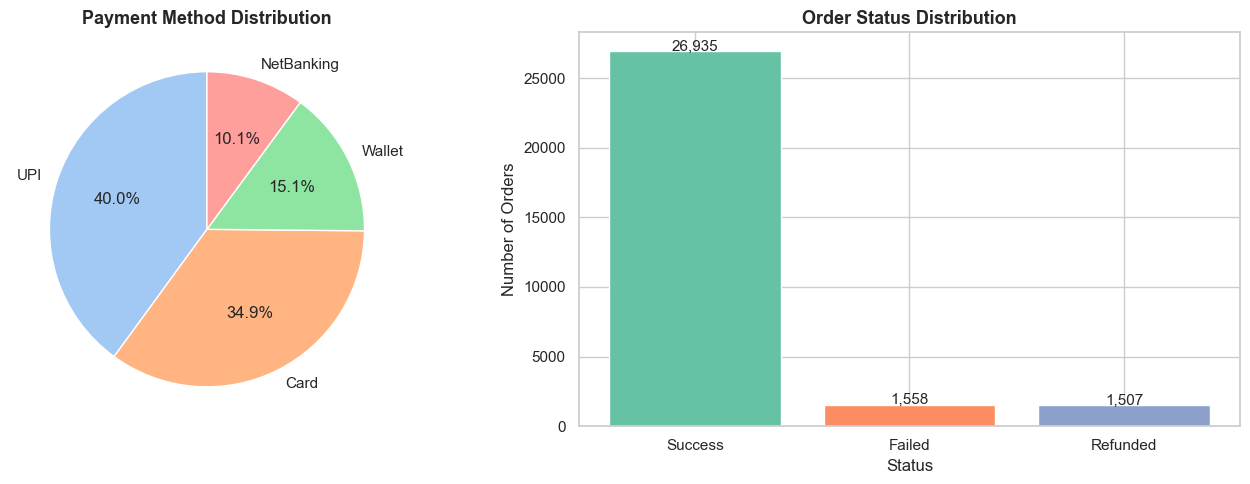

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Payment Method
pm = transactions['payment_method'].value_counts()
axes[0].pie(pm, labels=pm.index, autopct='%1.1f%%',
            startangle=90, colors=sns.color_palette('pastel', len(pm)))
axes[0].set_title('Payment Method Distribution', fontsize=13, fontweight='bold')

# Order Status
os_counts = transactions['order_status'].value_counts()
axes[1].bar(os_counts.index, os_counts.values,
            color=sns.color_palette('Set2', len(os_counts)))
axes[1].set_title('Order Status Distribution', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Status')
axes[1].set_ylabel('Number of Orders')
for i, (idx, val) in enumerate(os_counts.items()):
    axes[1].text(i, val + 50, f'{val:,}', ha='center', fontsize=11)

plt.tight_layout()
plt.savefig('E:\\Data Analyst Projects\\Projects\\Cartly Analytics\\report\\01_transactions_overview.png', dpi=150, bbox_inches='tight')
plt.show()

### 💡 Business Insight — Transactions

> **Failed/cancelled transactions represent lost revenue** — understanding the reason for failures (payment gateway issues, UX friction, trust barriers) can directly recover revenue.
>
> **NetBanking and Card are popular payment methods** — ensuring these work flawlessly, especially on mobile, is critical given our mobile-heavy user base.

---
## 📋 Step 8 — Data Quality Summary

Before analysis, let's confirm there are no major data quality issues.

In [25]:
datasets = {
    'users':        users,
    'sessions':     sessions,
    'events':       events,
    'products':     products,
    'transactions': transactions
}

print(f'{'Dataset':<15} {'Rows':>8} {'Cols':>6} {'Missing %':>12} {'Duplicates':>12}')
print('-' * 57)

for name, df in datasets.items():
    missing_pct = (df.isnull().sum().sum() / (df.shape[0] * df.shape[1]) * 100)
    dups = df.duplicated().sum()
    print(f'{name:<15} {df.shape[0]:>8,} {df.shape[1]:>6} {missing_pct:>11.1f}% {dups:>12,}')

Dataset             Rows   Cols    Missing %   Duplicates
---------------------------------------------------------
users             10,000      8         0.0%            0
sessions         100,000      9         0.0%            0
events           500,000      7        10.2%            0
products             200      8         0.0%            0
transactions      30,000      9         0.0%            0


---
## ✅ Summary — What We Learned

| Dataset | Records | Key Takeaway |
|---|---|---|
| Users | 10,000 | 65% mobile users, organic + referral drive sign-ups |
| Sessions | 100,000 | Organic leads traffic; bounce rate needs investigation |
| Events | 500,000 | 88.6% page views — conversion funnel is very top-heavy |
| Products | 200 | Diverse catalog; some inactive products |
| Transactions | 30,000 | Revenue engine — card & netbanking dominate |

